In [1]:
import os

# --- Path setup: works in Colab AND locally ---
try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/nassau-shipping-analysis"
except ImportError:
    # Running locally – notebook is inside <project>/notebook/
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
    if not os.path.isdir(os.path.join(PROJECT_ROOT, "data")):
        PROJECT_ROOT = os.getcwd()  # fallback: running from project root

RAW_DIR       = os.path.join(PROJECT_ROOT, "data", "raw")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "Processed")
REPORTS_DIR   = os.path.join(PROJECT_ROOT, "reports")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data dir: {RAW_DIR}")
print(f"Processed dir: {PROCESSED_DIR}")

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(os.path.join(RAW_DIR, "nassau_distributor.csv"))

In [4]:
df.sample(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
5441,5442,US-2023-106313-CHO-SCR-58000,22-08-2025,15-02-2029,Standard Class,106313,United States,Seattle,Washington,98105,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
81,82,US-2021-134103-CHO-NUT-13000,30-01-2024,28-07-2026,Standard Class,134103,United States,Detroit,Michigan,48234,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00
8185,8186,US-2024-103478-CHO-FUD-51000,21-07-2025,14-01-2030,Second Class,103478,United States,Aurora,Illinois,60505,Chocolate,Interior,CHO-FUD-51000,Wonka Bar - Fudge Mallows,25.20,7,16.80,8.40
1706,1707,US-2021-164721-CHO-MIL-31000,25-11-2024,20-05-2027,Second Class,164721,United States,Brentwood,California,94513,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,19.50,6,12.66,6.84
3648,3649,US-2022-144519-CHO-NUT-13000,13-11-2024,09-05-2028,Standard Class,144519,United States,Helena,Montana,59601,Chocolate,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,24.43,7,17.43,7.00
854,855,US-2021-126361-CHO-SCR-58000,04-08-2024,30-01-2027,Second Class,126361,United States,Pleasant Grove,Utah,84062,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,28.80,8,20.00,8.80
3072,3073,US-2022-104626-CHO-FUD-51000,01-09-2024,29-02-2028,Standard Class,104626,United States,Franklin,Massachusetts,2038,Chocolate,Atlantic,CHO-FUD-51000,Wonka Bar - Fudge Mallows,18.00,5,12.00,6.00
3776,3777,US-2022-123113-CHO-NUT-13000,23-11-2024,19-05-2028,Second Class,123113,United States,Morristown,New Jersey,7960,Chocolate,Atlantic,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
4310,4311,US-2023-112396-CHO-SCR-58000,09-02-2025,05-08-2028,Standard Class,112396,United States,San Francisco,California,94110,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20
3952,3953,US-2022-135622-CHO-NUT-13000,08-12-2024,02-06-2028,Second Class,135622,United States,Fort Worth,Texas,76106,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,20.94,6,14.94,6.00


In [5]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,int64
Country/Region,object
City,object
State/Province,object
Postal Code,object


In [6]:
df.dtypes.unique()

array([dtype('int64'), dtype('O'), dtype('float64')], dtype=object)

In [7]:
df.shape

(10194, 18)

In [8]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [9]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


In [10]:
for col in ['Ship Mode', 'Division', 'Region', 'Country/Region']:
    df[col].unique()

In [11]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
3417,3418,US-2022-124107-CHO-NUT-13000,09-10-2024,03-04-2028,Second Class,124107,United States,Ann Arbor,Michigan,48104,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
512,513,US-2021-152443-CHO-MIL-31000,21-05-2024,16-11-2026,Standard Class,152443,United States,Lawrence,Massachusetts,1841,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
4035,4036,US-2022-147830-CHO-NUT-13000,15-12-2024,09-06-2028,First Class,147830,United States,Newark,Ohio,43055,Chocolate,Atlantic,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,20.94,6,14.94,6.00
7134,7135,US-2024-102834-CHO-MIL-31000,09-03-2025,03-09-2029,Standard Class,102834,United States,San Francisco,California,94110,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
4216,4217,US-2023-152072-CHO-MIL-31000,15-01-2025,11-07-2028,Standard Class,152072,United States,Westfield,New Jersey,7090,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28


In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y', errors='coerce')

In [13]:
df['Order Date'].isnull().sum()

np.int64(0)

In [14]:
df['Ship Date'].isnull().sum()

np.int64(0)

In [15]:
## checking invalid dates

In [16]:
invalid_dates = df[df['Ship Date'] < df['Order Date']]

In [17]:
len(invalid_dates)

0

In [18]:
df = df[df['Ship Date'] >= df['Order Date']].copy()

In [19]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
9256,9257,US-2024-143567-CHO-FUD-51000,2025-11-02,2030-04-28,Second Class,143567,United States,Henderson,Kentucky,42420,Chocolate,Gulf,CHO-FUD-51000,Wonka Bar - Fudge Mallows,14.4,4,9.60,4.80
6288,6289,US-2023-158575-CHO-MIL-31000,2025-11-18,2029-05-16,Standard Class,158575,United States,Kent,Ohio,44240,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,19.5,6,12.66,6.84
2636,2637,US-2022-132836-CHO-MIL-31000,2024-06-01,2027-11-26,Standard Class,132836,United States,Detroit,Michigan,48227,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.5,2,4.22,2.28
9641,9642,US-2024-133312-CHO-SCR-58000,2025-11-25,2030-05-22,Standard Class,133312,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.8,3,7.50,3.30
9257,9258,US-2024-120061-CHO-MIL-31000,2025-11-02,2030-04-30,Second Class,120061,United States,Springfield,Ohio,45503,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.5,2,4.22,2.28


In [20]:
## converting string to readable string format

In [21]:
text_cols = ['Ship Mode', 'Division', 'Region', 'State/Province', 'City', 'Country/Region']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

In [22]:
df['Ship Mode'].unique()

array(['Standard Class', 'First Class', 'Second Class', 'Same Day'],
      dtype=object)

In [23]:
ship_mode_map = {
    'Standard Class': 'Standard Class',
    'First Class': 'First Class',
    'Second Class': 'Second Class',
    'Same Day': 'Same Day'
}

In [24]:
df['Ship Mode'] = df['Ship Mode'].map(ship_mode_map)


In [25]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
1233,1234,US-2021-133130-CHO-TRI-54000,2024-09-27,2027-03-24,Standard Class,133130,United States,San Diego,California,92037,Chocolate,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,18.75,5,12.25,6.50
4449,4450,US-2023-158834-CHO-SCR-58000,2025-03-13,2028-09-05,First Class,158834,United States,Scottsdale,Arizona,85254,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20
1067,1068,US-2021-131870-CHO-SCR-58000,2024-09-09,2027-03-04,First Class,131870,United States,Lancaster,Ohio,43130,Chocolate,Atlantic,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,21.60,6,15.00,6.60
6932,6933,US-2024-104619-CHO-NUT-13000,2025-01-24,2029-07-21,Standard Class,104619,United States,San Jose,California,95123,Chocolate,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3806,3807,US-2022-163762-CHO-MIL-31000,2024-11-27,2028-05-23,Standard Class,163762,United States,New York City,New York,10024,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
for col in ['Sales','Units','Gross Profit','Cost']:
  print(df[col].min(),
  df[col].max()),
  print((df[col]<0).sum())

1.25 260.0
0
1 14
0
0.25 130.0
0
0.6 130.0
0


In [28]:
df.shape

(10194, 18)

In [29]:
df['Product Name'].unique()

array(['Wonka Bar - Milk Chocolate', 'Wonka Bar - Triple Dazzle Caramel',
       'Wonka Bar - Nutty Crunch Surprise',
       'Wonka Bar -Scrumdiddlyumptious', 'Wonka Bar - Fudge Mallows',
       'Wonka Gum', 'Kazookles', 'Lickable Wallpaper',
       'Fizzy Lifting Drinks', 'Laffy Taffy', 'SweeTARTS', 'Nerds',
       'Hair Toffee', 'Everlasting Gobstopper', 'Fun Dip'], dtype=object)

In [30]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

In [31]:
df['Shipping Lead Time']=(df['Ship Date']-df['Order Date']).dt.days
df.sample()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Lead Time
1968,1969,US-2021-139598-CHO-MIL-31000,2024-12-26,2027-06-23,Standard Class,139598,United States,Philadelphia,Pennsylvania,19134,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.5,2,4.22,2.28,909


In [32]:
df['Shipping Lead Time'].describe()

,Shipping Lead Time
count,10194.000000
mean,1320.841868
std,262.444892
min,904.000000
25%,1271.000000
50%,1274.000000
75%,1638.000000
max,1642.000000


In [33]:
print((df['Shipping Lead Time'] >= 0).sum())
print((df['Shipping Lead Time'] <= 365).sum())

10194
0


In [34]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Lead Time
4532,4533,US-2023-166674-CHO-TRI-54000,2025-04-01,2028-09-23,Second Class,166674,United States,Auburn,New York,13021,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,1271
902,903,US-2021-109897-CHO-MIL-31000,2024-08-12,2027-02-06,Standard Class,109897,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,908
4752,4753,US-2023-164672-CHO-MIL-31000,2025-05-08,2028-11-02,Second Class,164672,United States,Dover,Delaware,19901,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,1274
2366,2367,US-2022-125563-CHO-TRI-54000,2024-04-11,2027-10-08,Standard Class,125563,United States,Tampa,Florida,33614,Chocolate,Gulf,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,1275
7598,7599,US-2024-118199-CHO-FUD-51000,2025-05-09,2029-11-01,First Class,118199,United States,Seattle,Washington,98105,Chocolate,Pacific,CHO-FUD-51000,Wonka Bar - Fudge Mallows,10.80,3,7.20,3.60,1637


In [35]:
print(df.shape)

(10194, 19)


In [36]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order DayOfWeek'] = df['Order Date'].dt.day_name()
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Product Name,Sales,Units,Gross Profit,Cost,Shipping Lead Time,Order Year,Order Month,Order Quarter,Order DayOfWeek
8805,8806,CA-2024-153738-CHO-SCR-58000,2025-09-20,2030-03-15,First Class,153738,Canada,Toronto,Ontario,M2N,...,Wonka Bar -Scrumdiddlyumptious,21.60,6,15.00,6.60,1637,2025,9,3,Saturday
5124,5125,US-2023-110044-CHO-MIL-31000,2025-06-28,2028-12-22,Second Class,110044,United States,Chicago,Illinois,60610,...,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,1273,2025,6,2,Saturday
87,88,US-2021-123400-CHO-TRI-54000,2024-02-02,2026-08-02,Standard Class,123400,United States,Saint Petersburg,Florida,33710,...,Wonka Bar - Triple Dazzle Caramel,18.75,5,12.25,6.50,912,2024,2,1,Friday
9064,9065,US-2024-152933-CHO-NUT-13000,2025-10-12,2030-04-08,Standard Class,152933,United States,Dallas,Texas,75081,...,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00,1639,2025,10,4,Sunday
7559,7560,US-2024-128755-CHO-MIL-31000,2025-05-04,2029-10-29,Standard Class,128755,United States,Newport News,Virginia,23602,...,Wonka Bar - Milk Chocolate,16.25,5,10.55,5.70,1639,2025,5,2,Sunday


In [37]:
## from our last product name code

In [38]:
product_to_factory = {
    'Wonka Bar - Nutty Crunch Surprise': "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows': "Lot's O' Nuts",
    'Wonka Bar -Scrumdiddlyumptious': "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate': "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel': "Wicked Choccy's",
    'Laffy Taffy': 'Sugar Shack',
    'SweeTARTS': 'Sugar Shack',
    'Nerds': 'Sugar Shack',
    'Fun Dip': 'Sugar Shack',
    'Fizzy Lifting Drinks': 'Sugar Shack',
    'Everlasting Gobstopper': 'Secret Factory',
    'Hair Toffee': 'The Other Factory',
    'Lickable Wallpaper': 'Secret Factory',
    'Wonka Gum': 'Secret Factory',
    'Kazookles': 'The Other Factory'
}

In [39]:
df['Factory'] = df['Product Name'].map(product_to_factory)
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Sales,Units,Gross Profit,Cost,Shipping Lead Time,Order Year,Order Month,Order Quarter,Order DayOfWeek,Factory
7129,7130,US-2024-155698-OTH-GUM-21000,2025-03-08,2029-09-01,First Class,155698,United States,Columbus,Georgia,31907,...,10.00,8,5.20,4.8,1638,2025,3,1,Saturday,Secret Factory
8271,8272,US-2024-128328-CHO-FUD-51000,2025-08-05,2030-01-30,Standard Class,128328,United States,Indianapolis,Indiana,46203,...,21.60,6,14.40,7.2,1639,2025,8,3,Tuesday,Lot's O' Nuts
8503,8504,US-2024-111220-CHO-TRI-54000,2025-09-02,2030-03-01,Standard Class,111220,United States,Chicago,Illinois,60653,...,15.00,4,9.80,5.2,1641,2025,9,3,Tuesday,Wicked Choccy's
1372,1373,US-2021-155264-CHO-TRI-54000,2024-10-19,2027-04-14,Second Class,155264,United States,San Francisco,California,94110,...,18.75,5,12.25,6.5,907,2024,10,4,Saturday,Wicked Choccy's
4842,4843,US-2023-143714-CHO-SCR-58000,2025-05-23,2028-11-16,Standard Class,143714,United States,Philadelphia,Pennsylvania,19120,...,3.60,1,2.50,1.1,1273,2025,5,2,Friday,Lot's O' Nuts


In [40]:
unmapped = df[df['Factory'].isnull()]['Product Name'].unique()
if len(unmapped) > 0:
    print(f"Warning: Unmapped products: {unmapped}")
    df['Factory'] = df['Factory'].fillna('Unknown')


In [41]:
#from given data

In [42]:
factory_coords = {
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.11914, -96.18115),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.1175, -89.971107)
}

In [43]:
df['Factory Latitude'] = df['Factory'].map(lambda x: factory_coords.get(x, (None, None))[0])
df['Factory Longitude'] = df['Factory'].map(lambda x: factory_coords.get(x, (None, None))[1])
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Gross Profit,Cost,Shipping Lead Time,Order Year,Order Month,Order Quarter,Order DayOfWeek,Factory,Factory Latitude,Factory Longitude
204,205,US-2021-118339-CHO-FUD-51000,2024-03-17,2026-09-14,Standard Class,118339,United States,Lakeville,Minnesota,55044,...,14.40,7.20,911,2024,3,1,Sunday,Lot's O' Nuts,32.881893,-111.768036
5598,5599,US-2023-136595-CHO-MIL-31000,2025-09-05,2029-02-27,First Class,136595,United States,Houston,Texas,77036,...,6.33,3.42,1271,2025,9,3,Friday,Wicked Choccy's,32.076176,-81.088371
3639,3640,US-2022-153283-CHO-FUD-51000,2024-11-12,2028-05-10,Standard Class,153283,United States,New York City,New York,10035,...,4.80,2.40,1275,2024,11,4,Tuesday,Lot's O' Nuts,32.881893,-111.768036
5631,5632,US-2023-133123-CHO-SCR-58000,2025-09-06,2029-03-03,Standard Class,133123,United States,Thomasville,North Carolina,27360,...,5.00,2.20,1274,2025,9,3,Saturday,Lot's O' Nuts,32.881893,-111.768036
2080,2081,US-2022-156755-CHO-TRI-54000,2024-01-12,2027-07-11,Standard Class,156755,United States,Newark,Delaware,19711,...,7.35,3.90,1276,2024,1,1,Friday,Wicked Choccy's,32.076176,-81.088371


In [44]:
df['Route_State'] = df['Factory'] + ' → ' + df['State/Province']
df['Route_Region'] = df['Factory'] + ' → ' + df['Region']
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Shipping Lead Time,Order Year,Order Month,Order Quarter,Order DayOfWeek,Factory,Factory Latitude,Factory Longitude,Route_State,Route_Region
8020,8021,US-2024-102946-CHO-FUD-51000,2025-06-30,2029-12-26,Standard Class,102946,United States,Las Vegas,Nevada,89115,...,1640,2025,6,2,Monday,Lot's O' Nuts,32.881893,-111.768036,Lot's O' Nuts → Nevada,Lot's O' Nuts → Pacific
3007,3008,US-2022-144267-CHO-FUD-51000,2024-08-21,2028-02-13,First Class,144267,United States,San Francisco,California,94110,...,1271,2024,8,3,Wednesday,Lot's O' Nuts,32.881893,-111.768036,Lot's O' Nuts → California,Lot's O' Nuts → Pacific
6100,6101,US-2023-109365-CHO-FUD-51000,2025-11-03,2029-04-30,Standard Class,109365,United States,Los Angeles,California,90049,...,1274,2025,11,4,Monday,Lot's O' Nuts,32.881893,-111.768036,Lot's O' Nuts → California,Lot's O' Nuts → Pacific
1769,1770,US-2021-117744-CHO-TRI-54000,2024-12-02,2027-05-29,Standard Class,117744,United States,Corpus Christi,Texas,78415,...,908,2024,12,4,Monday,Wicked Choccy's,32.076176,-81.088371,Wicked Choccy's → Texas,Wicked Choccy's → Interior
4992,4993,US-2023-139941-CHO-FUD-51000,2025-06-12,2028-12-07,Standard Class,139941,United States,Long Beach,New York,11561,...,1274,2025,6,2,Thursday,Lot's O' Nuts,32.881893,-111.768036,Lot's O' Nuts → New York,Lot's O' Nuts → Atlantic


In [45]:
df['Region'].sample(5)

,Region
5126,Gulf
8796,Atlantic
9357,Pacific
3957,Interior
2613,Pacific


In [46]:
df['Profit Margin %'] = (df['Gross Profit'] / df['Sales'] * 100).round(2)
df['Profit Margin %'].sample(5)

,Profit Margin %
4148,7.69
5990,69.44
9034,64.92
1475,69.44
1278,66.67


In [47]:
print(df[['Factory', 'Shipping Lead Time', 'Route_State', 'Route_Region']].head())
print(f"\nTotal routes (factory → state): {df['Route_State'].nunique()}")
print(f"Total routes (factory → region): {df['Route_Region'].nunique()}")

           Factory  Shipping Lead Time                     Route_State  \
0  Wicked Choccy's                 909         Wicked Choccy's → Texas   
1  Wicked Choccy's                 909      Wicked Choccy's → Illinois   
2    Lot's O' Nuts                 909        Lot's O' Nuts → Illinois   
3    Lot's O' Nuts                 909        Lot's O' Nuts → Illinois   
4  Wicked Choccy's                 912  Wicked Choccy's → Pennsylvania   

                 Route_Region  
0  Wicked Choccy's → Interior  
1  Wicked Choccy's → Interior  
2    Lot's O' Nuts → Interior  
3    Lot's O' Nuts → Interior  
4  Wicked Choccy's → Atlantic  

Total routes (factory → state): 196
Total routes (factory → region): 20


In [48]:
df.to_csv(os.path.join(PROCESSED_DIR, "cleaned_data.csv"), index=False)
print(f"Saved cleaned data ({df.shape[0]} rows, {df.shape[1]} cols) to {PROCESSED_DIR}/cleaned_data.csv")

In [51]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

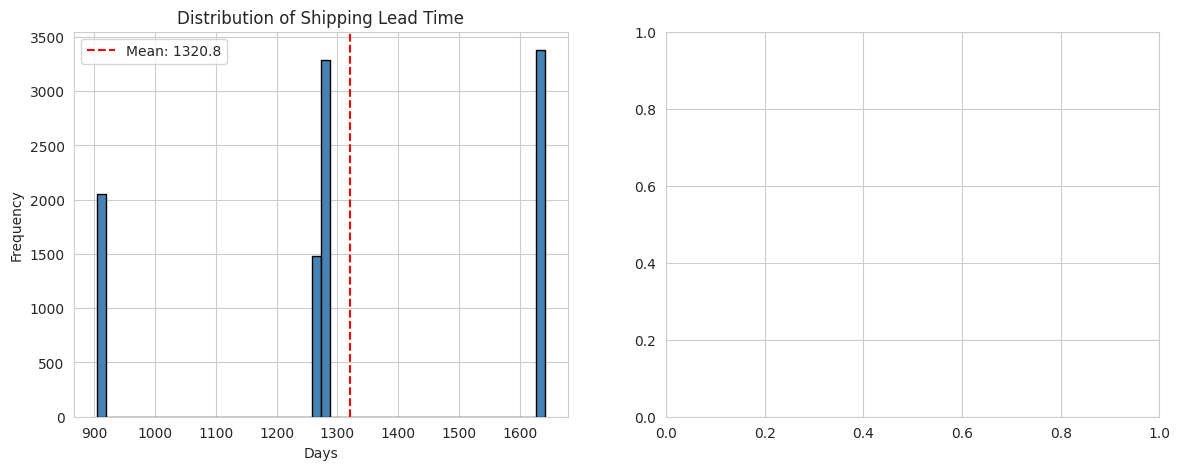

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Shipping Lead Time'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Distribution of Shipping Lead Time')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Shipping Lead Time'].mean(), color='red', linestyle='--', label=f"Mean: {df['Shipping Lead Time'].mean():.1f}")
axes[0].legend()

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(
    data=df,
    x="Ship Mode",
    y="Shipping Lead Time",
    ax=axes[1]
)

axes[1].set_title("Lead Time by Ship Mode")
axes[1].set_xlabel("Ship Mode")
axes[1].set_ylabel("Shipping Lead Time")

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "eda_lead_time.png"), dpi=120, bbox_inches="tight")
plt.show()

Text(0, 0.5, 'Number of Orders')

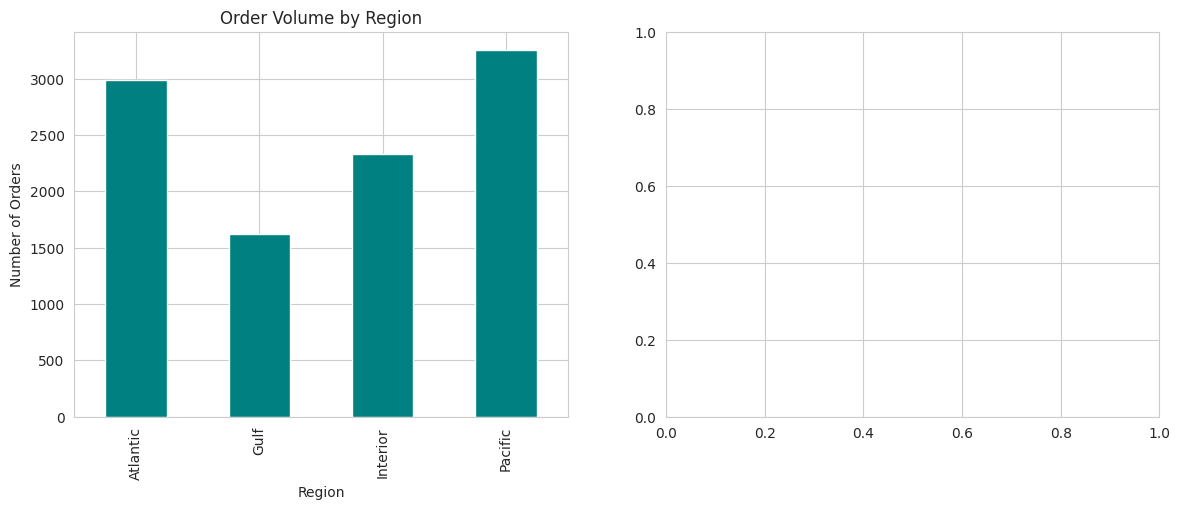

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.groupby('Region').size().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Order Volume by Region')
axes[0].set_ylabel('Number of Orders')

In [64]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
df.groupby("Division").size().plot(
    kind="bar",
    ax=axes[1],
    color="coral"
)

axes[1].set_title("Order Volume by Division")
axes[1].set_xlabel("Division")
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "eda_volume.png"), dpi=120, bbox_inches="tight")
plt.show()

In [60]:
monthly_orders = df.set_index("Order Date").resample("M").size()
plt.figure(figsize=(14, 5))
monthly_orders.plot(color="darkblue")
plt.title("Monthly Order Volume Over Time")
plt.xlabel("Month"); plt.ylabel("Orders")
plt.savefig(os.path.join(REPORTS_DIR, "eda_timeseries.png"), dpi=150, bbox_inches="tight")
plt.show()

In [66]:
numeric_cols = ["Sales", "Units", "Gross Profit", "Cost", "Shipping Lead Time", "Profit Margin %"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig(os.path.join(REPORTS_DIR, "eda_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()

In [67]:
print("=" * 60)
print("KEY EDA FINDINGS")
print("=" * 60)
print(f"Total orders: {len(df):,}")
print(f"Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"Avg lead time: {df['Shipping Lead Time'].mean():.2f} days")
print(f"Median lead time: {df['Shipping Lead Time'].median():.2f} days")
print(f"\nLead time by Ship Mode:")
print(df.groupby('Ship Mode')['Shipping Lead Time'].agg(['mean', 'median', 'std']).round(2))
print(f"\nLead time by Region:")
print(df.groupby('Region')['Shipping Lead Time'].agg(['mean', 'median']).round(2))
print(f"\nLead time by Factory:")
print(df.groupby('Factory')['Shipping Lead Time'].agg(['mean', 'median', 'count']).round(2))

KEY EDA FINDINGS
Total orders: 10,194
Date range: 2024-01-02 to 2025-12-31
Avg lead time: 1320.84 days
Median lead time: 1274.00 days

Lead time by Ship Mode:
                   mean  median     std
Ship Mode                              
First Class     1338.28  1272.0  265.63
Same Day        1333.44  1269.0  253.81
Second Class    1323.85  1273.0  261.81
Standard Class  1314.33  1274.0  262.40

Lead time by Region:
             mean  median
Region                   
Atlantic  1322.75  1274.0
Gulf      1311.37  1274.0
Interior  1323.09  1274.0
Pacific   1322.19  1274.0

Lead time by Factory:
                      mean  median  count
Factory                                  
Lot's O' Nuts      1321.23  1274.0   5692
Secret Factory     1321.87  1274.0    217
Sugar Shack        1340.03  1274.0     33
The Other Factory  1280.28  1273.0    100
Wicked Choccy's    1321.08  1274.0   4152


In [68]:
state_perf = df.groupby('State/Province').agg(
    Avg_Lead_Time=('Shipping Lead Time', 'mean'),
    Volume=('Order ID', 'count'),
    Total_Sales=('Sales', 'sum'),
    Avg_Profit_Margin=('Profit Margin %', 'mean')
).reset_index()

In [69]:
lead_time_threshold = state_perf['Avg_Lead_Time'].quantile(0.75)  # top 25% slowest
volume_threshold = state_perf['Volume'].quantile(0.75)  # top 25% by volume

In [70]:
state_perf['Is_Bottleneck'] = (
    (state_perf['Avg_Lead_Time'] >= lead_time_threshold) &
    (state_perf['Volume'] >= volume_threshold)
)

In [72]:
def perf_category(row):
    if row['Is_Bottleneck']:
        return 'Critical Bottleneck'
    elif row['Avg_Lead_Time'] >= lead_time_threshold:
        return 'Slow Route'
    elif row['Volume'] >= volume_threshold:
        return 'High-Volume Healthy'
    else:
        return 'Standard'

In [76]:
state_perf["Performance_Category"] = state_perf.apply(perf_category, axis=1)
state_perf = state_perf.round(2).sort_values("Avg_Lead_Time", ascending=False)
state_perf.to_csv(os.path.join(PROCESSED_DIR, "state_performance.csv"), index=False)
print(f"Saved state performance data ({len(state_perf)} states)")

In [79]:
print("Critical Bottlenecks:")
print(state_perf[state_perf['Performance_Category'] =='Critical Bottleneck'])
print(f"\nTop 10 slowest states:")
print(state_perf.nlargest(10, 'Avg_Lead_Time')[['State/Province', 'Avg_Lead_Time', 'Volume']])

Critical Bottlenecks:
   State/Province  Avg_Lead_Time  Volume  Total_Sales  Avg_Profit_Margin  \
50      Tennessee        1391.49     183      2383.56              66.25   
55     Washington        1360.66     506      6921.15              66.52   

    Is_Bottleneck Performance_Category  
50           True  Critical Bottleneck  
55           True  Critical Bottleneck  

Top 10 slowest states:
          State/Province  Avg_Lead_Time  Volume
56         West Virginia        1638.00       4
37          North Dakota        1637.86       7
47          Saskatchewan        1457.00       2
20              Manitoba        1455.33      12
15                  Iowa        1443.90      30
33            New Mexico        1441.84      37
53               Vermont        1438.91      11
44  Prince Edward Island        1420.30      10
49          South Dakota        1395.92      12
50             Tennessee        1391.49     183


In [80]:
ship_mode_analysis = df.groupby('Ship Mode').agg(
    Volume=('Order ID', 'count'),
    Avg_Lead_Time=('Shipping Lead Time', 'mean'),
    Median_Lead_Time=('Shipping Lead Time', 'median'),
    Lead_Time_Std=('Shipping Lead Time', 'std'),
    Total_Sales=('Sales', 'sum'),
    Avg_Sales_Per_Order=('Sales', 'mean'),
    Avg_Profit_Margin=('Profit Margin %', 'mean')
).round(2).reset_index()



In [82]:
ship_mode_analysis["Volume_%"] = (ship_mode_analysis["Volume"] / ship_mode_analysis["Volume"].sum() * 100).round(2)
ship_mode_analysis = ship_mode_analysis.sort_values("Avg_Lead_Time")
ship_mode_analysis.to_csv(os.path.join(PROCESSED_DIR, "ship_mode_analysis.csv"), index=False)
print(ship_mode_analysis)

In [81]:
ship_region = df.groupby(["Ship Mode", "Region"])["Shipping Lead Time"].mean().unstack().round(2)
print("\nLead time by Ship Mode × Region:")
print(ship_region)
ship_region.to_csv(os.path.join(PROCESSED_DIR, "ship_mode_region_pivot.csv"))

In [83]:
import sys